# RL2 - Notebook 1 - Simulations and Traces

In this notebook, you will use the MDPs objects to create a simulation object that can simulate the interaction between an agent and an MDP. You will also explore how a simulation creates a **trace** or **history**, a record of the agent-environment interaction, and how to evaluate the **return** of a trace.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from inst0075.rl.environment.simulation import Trace
from inst0075.rl.environment.simulation import Simulation
from inst0075.rl.environment.simulation import MDPSimulation

from inst0075.rl.algorithms.dynamic_programming import policy_evaluation
from inst0075.rl.algorithms.dynamic_programming import policy_iteration
from inst0075.rl.environment.states_and_actions import dominant_actions
from inst0075.rl.environment.states_and_actions import indices_to_names

from inst0075.rl.environment.states_and_actions import get_unbiased_policy
from inst0075.rl.environment.states_and_actions import choose_from_policy

import inst0075.rl.environment.model.example_mdps as example_mdps
import inst0075.rl.environment.model.example_grid_worlds as example_grid_worlds 

from inst0075.rl.environment.example_simulations import SimpleQueuingSim

from inst0075.rl.visualisation import (
    plot_policy_matrix,
)



### Simulating a trace from an MDP

MDPs and related model represent environments that can be interacted with by agents in a series of time-steps. Here we describe any such interactive environment as a simulation. This question investigates the code within the module `simulation.py` which can create simulation objects, and in particular those built around MDPs. You will explore simulations by editing and running the module `explore\_simulations\_and\_traces.py`.


`MDPSimulation` objects are defined in `inst0075.rl.environment.simulation` and use MDP models to simulate an environment. All `MDPSimulation` objects have a `run` function that generates random traces. Look at the code block below. Initially, this should:
1. Construct a Stair-Climbing MDP
1. Construct an unbiased policy for the MDP
1. Construct a `MDPSimulation` object from this (something you haven't seen before)
1. then run the simulation using the unbiased policy, to generate a random trace through the environment and print it to standard output
  
Run the code block and make sure you understand how the output is produced. Each trace is random. Run the code block again. Does it give a different trace?

In [2]:
# create an MDP object and an unbiased policy for this environment.
stair_mdp = example_mdps.stair_climbing_mdp()
unbiased_policy = get_unbiased_policy(
    stair_mdp.num_states, stair_mdp.num_actions)
# now construct an MDPSimulation object that can simulate interactions 
# between an agent and the MDP
stair_sim = MDPSimulation(stair_mdp)
# run a single episode of the environment and capture the trace, then print
trace = stair_sim.run(unbiased_policy)
print("trace = %s" % (trace,))

trace = s3, R, -1.0, s4, L, 1.0, s3, L, 1.0, s2, L, 1.0, s1, L, -10.0, P


## Simulate multiple traces


Now edit the block below, so that it generates 10 traces from the same simulation and prints each to standard output. Convince yourself that the output is random.

In [3]:
## TODO: Generate 10 traces from the stair_sim object
## and print them to screen.

## Calculate trace returns

Traces are also objects (`Trace`) with associated functionality (see `inst0075.rl.environment.simulation`). In particular, you can evaluate the return of `Trace` object called `trace` with `trace.trace_return(gamma)`. Edit the block below so to produce 10 traces and to calculates and print each trace's return for geometric discount `gamma = 0.9`

In [4]:
# Example code to calculates the return for a single trace.
trace.trace_return(0.9)

## TODO: Generate 10 traces from the stair_sim object
## calculate the return for each trace and print to screen.

-5.122

## Interacting with a simulation

For some of our algorithms, it will be necessary to choose actions and generate next states one step at a time. This is also possible with these objects. See the code below where the action and state for each time-step in a trace is generated one step at a time.

In [5]:
# Define some convenient short-hand variables
state_names = stair_sim.state_names
action_names = stair_sim.action_names

# Now lets step through the simlulation one state and action at a time.
# Initialise the state and choose first action.
s = stair_sim.reset()
a = choose_from_policy(unbiased_policy, s)
print("At time 0:")
print(f"\tState is {state_names[a]}")
print(f"\tAction choice is {action_names[a]}")

# For up to 10 time-steps
for t in range(1,11):
    print(f"At time {t}")
    s, r = stair_sim.next(a)
    print(f"\tReward is = {r:.2f}" )
    print(f"\tState is = {state_names[s]}" )
    if stair_sim.absorbing[s]:
        print(f"\tReached absorbing state. Episode ends.")
        break
    a = choose_from_policy(unbiased_policy, s)
    print(f"\tAction choice is: {action_names[a]}")
    

At time 0:
	State is s1
	Action choice is R
At time 1
	Reward is = -1.00
	State is = s4
	Action choice is: L
At time 2
	Reward is = 1.00
	State is = s3
	Action choice is: L
At time 3
	Reward is = 1.00
	State is = s2
	Action choice is: R
At time 4
	Reward is = -1.00
	State is = s3
	Action choice is: R
At time 5
	Reward is = -1.00
	State is = s4
	Action choice is: R
At time 6
	Reward is = -1.00
	State is = s5
	Action choice is: R
At time 7
	Reward is = 10.00
	State is = G
	Reached absorbing state. Episode ends.


## Direct simluations

In some cases, it is inconvenient, inefficient or intractable to describe the model explicitly as an MDP, even if the system you wish to describe is a MDP. The code below creates a simulation of a queuing system such as you might find on a load balancing computer system. The simulation below is based on an example from the Sutton and Barto textbook [SB12], the text is repeated here for convenience:

> Example 11.1: **An Access-Control Queuing Task** This is a decision
task involving access control to a set of n servers. Customers of four different
priorities arrive at a single queue. If given access to a server, the customers
pay a reward of 1, 2, 4, or 8, depending on their priority, with higher priority
customers paying more. In each time step, the customer at the head of the
queue is either accepted (assigned to one of the servers) or rejected (removed
from the queue). In either case, on the next time step the next customer
in the queue is considered. The queue never empties, and the proportion of
(randomly distributed) high priority customers in the queue is h. Of course a
customer can be served only if there is a free server. Each busy server becomes
free with probability p on each time step. Although we have just described
them for definiteness, let us assume the statistics of arrivals and departures are
unknown. The task is to decide on each step whether to accept or reject the
next customer, on the basis of his priority and the number of free servers, so
as to maximize long-term reward without discounting.

For our implementation, states are represented as a tuple `(servers_busy, priority)` where `servers_busy` is the number of servers currently busy, and `priority` is the priority level of the next incoming job. Actions are `reject` (index `0`) or `accept` (index `1`). Below we first create the simulation and construct an unbiased policy. We then simulate a number of steps of the simulation.

Note that we do not need to explicitly construct the MDP transition probabilities or rewards as tensors. Instead, we define these programmatically in any way we choose. The transition dynamics and reward behaviours emerge from our interactions.

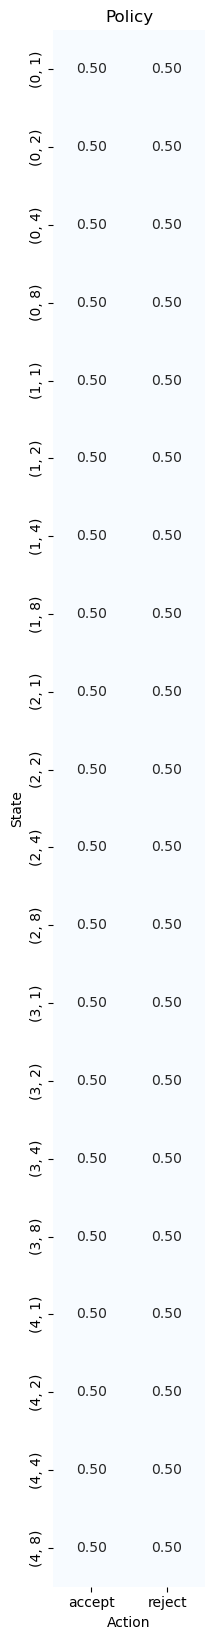

In [6]:
num_servers = 4
p = 0.06
max_steps = 10

# create an MDP object and an unbiased policy for this environment.
sim = SimpleQueuingSim(num_servers, p)
unbiased_policy = get_unbiased_policy(
    sim.num_states, sim.num_actions)
# Show heatmap of the policy
plot_policy_matrix(unbiased_policy, sim, scale=0.75)

In [7]:
# run a single episode of the environment and capture the trace, then print
trace = sim.run(unbiased_policy, max_steps=max_steps)
print("trace.states = %r" % (trace.states,) )
print("trace.actions = %r" % (trace.actions,) )
print("trace.rewards = %r" % (trace.rewards,) )
print("trace = %s" % (trace,))

trace.states = [2, 7, 9, 15, 14, 11, 12, 13, 19, 19, 19]
trace.actions = [0, 0, 0, 1, 1, 0, 1, 0, 1, 0]
trace.rewards = [4, 8, 2, 0, 0, 8, 0, 2, 0, -8]
trace = (0, 4), accept, 4, (1, 8), accept, 8, (2, 2), accept, 2, (3, 8), reject, 0, (3, 4), reject, 0, (2, 8), accept, 8, (3, 1), reject, 0, (3, 2), accept, 2, (4, 8), reject, 0, (4, 8), accept, -8, (4, 8)


## Summary and reflection

In this notebook, we saw how to:
* Construct simlulations from MDP models
* Given a control policy simulate a trace, or multiple traces, from initial state to absorbing state
* Evaluate the return for a given trace (the sum of geometrically discounted rewards)
* Interact with a simulation step-by-step.
* Create a simulation directly without using an underlying MDP model.

You can explore different MDP models and simulations, as well as trying to implement your own simulations.
